# Least Squares Regression


## Setup

Run this cell once to load packages and data for today

In [11]:
library(tidyverse)
library(palmerpenguins)


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw




---

## Part 1: From Correlation to Regression

### Where is the prediction line?

In lecture we saw several scatter plots. The **correlation** $r$ tells us how tightly $x$ and $y$ move together, while **regression** uses that same idea to draw the best-fitting line.

In standardized (SD) units, the regression line is:

$$
\frac{\hat{y} - \bar{y}}{\sigma_y} = r \times \frac{x - \bar{x}}{\sigma_x}
$$

Re-arranged into slope–intercept form:

$$
\hat{y} = b_1 x + b_0
\qquad
b_1 = r \cdot \frac{\sigma_y}{\sigma_x},
\qquad
b_0 = \bar{y} - b_1 \bar{x}
$$

Since $\sigma_{\hat{y}} = |r| \, \sigma_y$, predicted values vary **less** than the actual data whenever $|r| < 1$.

### Demo: Scatter plots with different correlations

r = 0.99 


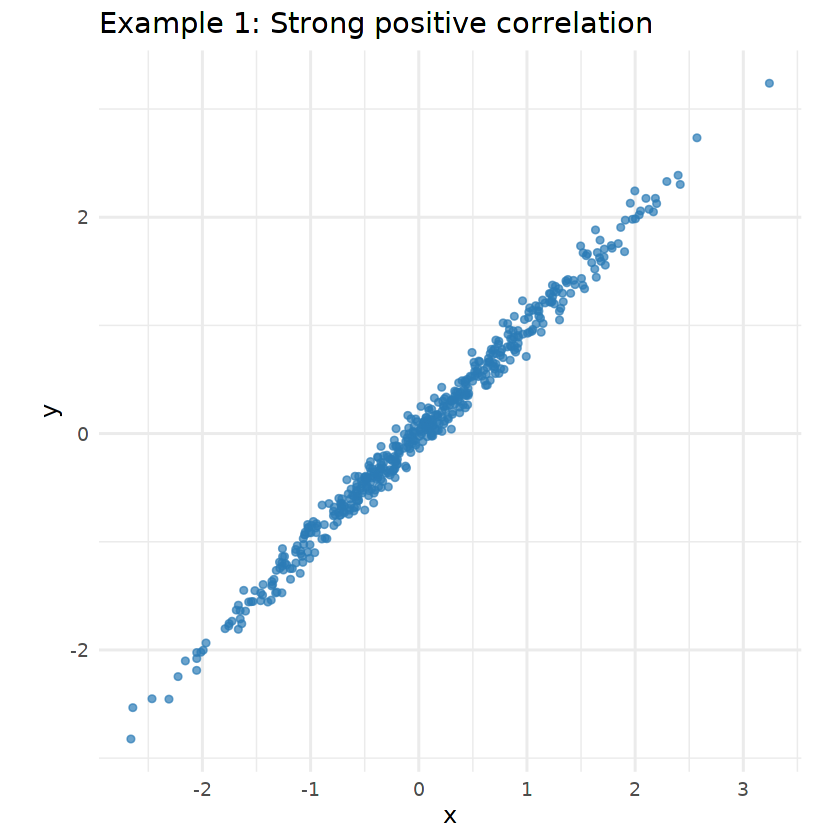

In [4]:
# Example 1: Strong positive correlation
set.seed(123)
x <- rnorm(500)
y <- x + rnorm(500, sd = 0.1)
cat("r =", round(cor(x, y), 2), "\n")

ggplot(data.frame(x, y), aes(x, y)) +
  geom_point(color = "#2C7BB6", alpha = 0.7) +
  coord_fixed() +
  theme_minimal(base_size = 14) +
  labs(title = "Example 1: Strong positive correlation")

r = -0.06 


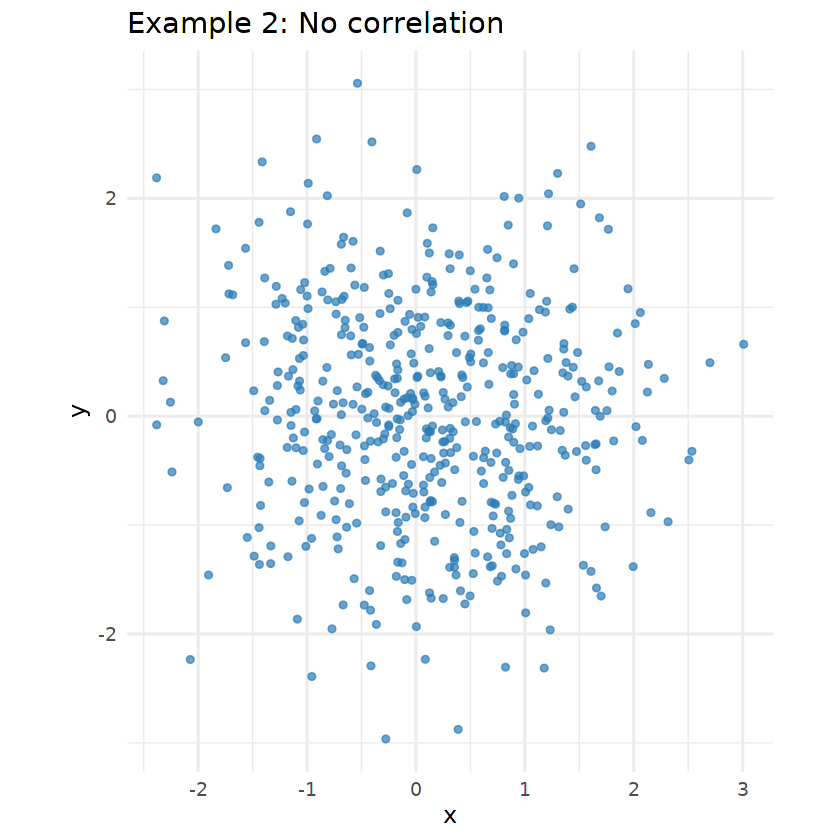

In [5]:
# Example 2: No correlation
set.seed(456)
x <- rnorm(500)
y <- rnorm(500)
cat("r =", round(cor(x, y), 2), "\n")

ggplot(data.frame(x, y), aes(x, y)) +
  geom_point(color = "#2C7BB6", alpha = 0.7) +
  coord_fixed() +
  theme_minimal(base_size = 14) +
  labs(title = "Example 2: No correlation")

r = 0.66 


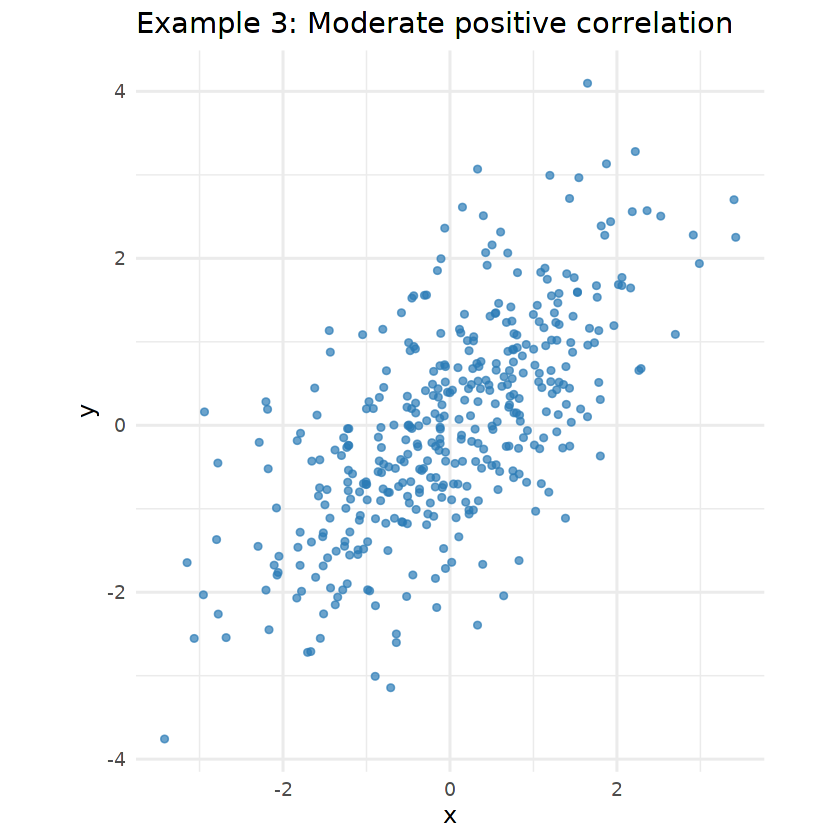

In [6]:
# Example 3: Moderate positive correlation
set.seed(2025)
x <- rnorm(400, sd = 1.2)
y <- 0.7 * x + rnorm(400, sd = 0.9)
cat("r =", round(cor(x, y), 2), "\n")

ggplot(data.frame(x, y), aes(x, y)) +
  geom_point(color = "#2C7BB6", alpha = 0.7) +
  coord_fixed() +
  theme_minimal(base_size = 14) +
  labs(title = "Example 3: Moderate positive correlation")

---

## Your Turn: Predicting from Correlation

A course has a midterm and a final:

| | Mean | SD |
|---|---|---|
| Midterm (X) | 70 | 10 |
| Final (Y) | 50 | 12 |

The scatter diagram has an oval shape with $r = 0.75$.

**Questions:**
- What is the expected final score for a student who scored 90 on the midterm?
- What about a student who scored 60?

Work through it by hand, then check with the code below.

In [ ]:
# Fill in values from above
x_bar <- NULL; s_x <- NULL
y_bar <- NULL; s_y <- NULL
r     <- NULL

# Step 1: Calculate Slope using the formula
b1 <- NULL
b1

# Step 2: Calculate Intercept using the formula
b0 <- NULL
b0

# Step 3: What is the regression line?
# Write in the comment. 


# Step 4: Predictions
predict_score <- function(x){# add a definition with the regression line formula}
predict_score(90)
predict_score(60)

### Tiny three-point example

Three points: $(1,1),\,(2,2),\,(3,3)$. Fix the intercept at 0 and vary the slope. How does SSR change?

In [14]:
simple_data <- tibble(x = c(1, 2, 3), y = c(1, 2, 3))

ssr_for_slope <- function(b1) {
  preds <- b1 * simple_data$x
  sum((simple_data$y - preds)^2)
}

cost_curve <- tibble(slope = seq(-2, 4, by = 0.5)) |>
  mutate(ssr = map_dbl(slope, ssr_for_slope))

cost_curve

slope,ssr
<dbl>,<dbl>
-2.0,126.0
-1.5,87.5
-1.0,56.0
-0.5,31.5
0.0,14.0
0.5,3.5
1.0,0.0
1.5,3.5
2.0,14.0


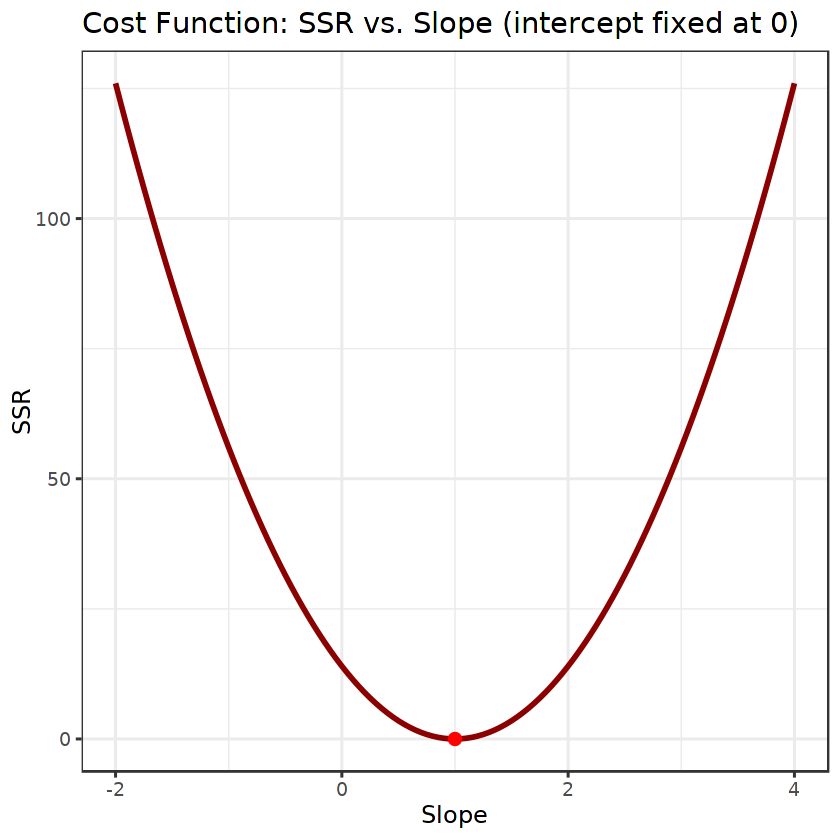

In [15]:
# Plot the cost (parabola) curve
cost_fine <- tibble(slope = seq(-2, 4, by = 0.05)) |>
  mutate(ssr = map_dbl(slope, ssr_for_slope))

ggplot(cost_fine, aes(x = slope, y = ssr)) +
  geom_line(color = "darkred", linewidth = 1.2) +
  geom_point(data = filter(cost_fine, slope == 1),
             color = "red", size = 3) +
  labs(
    title = "Cost Function: SSR vs. Slope (intercept fixed at 0)",
    x = "Slope", y = "SSR"
  ) +
  theme_bw(base_size = 14)

The minimum is at slope = 1 (SSR = 0). The cost curve is a **parabola** — this is why there's always a unique minimum.

---

## Part 4: From Linear to Nonlinear Models

We started with a **linear model**: a straight line relating $x$ and $y$:
$$\hat{y} = b_0 + b_1 x$$

But what if the relationship bends or curves? We can extend to **polynomial regression** by adding powers of $x$:

| Model | Equation | Shape |
|---|---|---|
| Linear | $\hat{y} = b_0 + b_1 x$ | Straight line |
| Quadratic | $\hat{y} = b_0 + b_1 x + b_2 x^2$ | U- or ∩-shaped |
| Cubic | $\hat{y} = b_0 + b_1 x + b_2 x^2 + b_3 x^3$ | S-shaped |

Importantly, we are **still using least squares** — minimizing the same SSR. The model is still *linear in the parameters* $(b_0, b_1, b_2, \ldots)$, even when the curve isn't straight.

### Shotput Example: Linear vs. Quadratic Fit

A [study](https://digitalcommons.wku.edu/ijes/vol6/iss2/10/) postulated a quadratic relationship between weight lifted and shot put distance.

In [10]:
shotput <- read_csv("shotput.csv", show_col_types = FALSE)
glimpse(shotput)

Rows: 28
Columns: 2
$ `Weight Lifted`     <dbl> 37.5, 51.5, 61.3, 61.3, 63.6, 66.1, 70.0, 92.7, 90…
$ `Shot Put Distance` <dbl> 6.4, 10.2, 12.4, 13.0, 13.2, 13.0, 12.7, 13.9, 15.…


In [ ]:
# Fit linear and quadratic models
linear_fit <- lm(`Shot Put Distance` ~ `Weight Lifted`, data = shotput)
quad_fit   <- lm(`Shot Put Distance` ~ `Weight Lifted` + I(`Weight Lifted`^2), data = shotput)

# augment() returns original data + fitted values and residuals
aug_lin  <- augment(linear_fit)
aug_quad <- augment(quad_fit)

In [ ]:
library(patchwork)

p1 <- ggplot(shotput, aes(x = `Weight Lifted`, y = `Shot Put Distance`)) +
  geom_point(alpha = 0.6) +
  geom_line(data = aug_lin, aes(y = .fitted), color = "#8E2C90", linewidth = 1) +
  labs(title = "Linear Fit",
       x = "Weight Lifted (kg)", y = "Shot Put Distance (m)") +
  theme_bw(base_size = 14)

p2 <- ggplot(shotput, aes(x = `Weight Lifted`, y = `Shot Put Distance`)) +
  geom_point(alpha = 0.6) +
  geom_line(data = aug_quad, aes(y = .fitted), color = "steelblue4", linewidth = 1) +
  labs(title = "Quadratic Fit",
       x = "Weight Lifted (kg)", y = "Shot Put Distance (m)") +
  theme_bw(base_size = 14)

p1 + p2

In [ ]:
# Compare SSR
c(
  SSR_linear    = sum(residuals(linear_fit)^2),
  SSR_quadratic = sum(residuals(quad_fit)^2)
)

Least squares still minimizes SSR — but if the **model form** is wrong (a straight line for a curved relationship), the minimized SSR will still be large.

---

## Try it Out!

**Exercise 1:** Replace `Weight Lifted` with a log transform. Does it fit better?

---

## Part 5: Training vs. Testing Data

A model that fits the training data extremely well may not generalize to new data.

- **Training data**: used to estimate model parameters (fit)
- **Testing data**: used to evaluate how well the model generalizes

The goal isn't the *lowest SSR on training data* — it's the *lowest error on unseen data*.

In [ ]:
set.seed(42)

x <- seq(0, 10, length.out = 50)
y <- 3 + 2 * x + rnorm(50, sd = 3)

train_idx <- sample(1:50, 35)
train <- tibble(x = x[train_idx],  y = y[train_idx])
test  <- tibble(x = x[-train_idx], y = y[-train_idx])

model <- lm(y ~ x, data = train)

ggplot() +
  geom_point(data = train, aes(x, y), color = "chartreuse4", alpha = 0.7) +
  geom_point(data = test,  aes(x, y), color = "firebrick",   alpha = 0.7) +
  geom_abline(intercept = coef(model)[1], slope = coef(model)[2],
              color = "goldenrod2", linewidth = 1.2) +
  labs(title = "Training (green) vs. Testing (red) Data",
       x = "x", y = "y") +
  theme_minimal(base_size = 14)

### Overfitting vs. Underfitting

- **Training error** always decreases as model complexity increases.
- **Test error** eventually increases — that's overfitting.
- The blue line (linear) underfits less than the dashed red line (degree-10 polynomial) overfits.

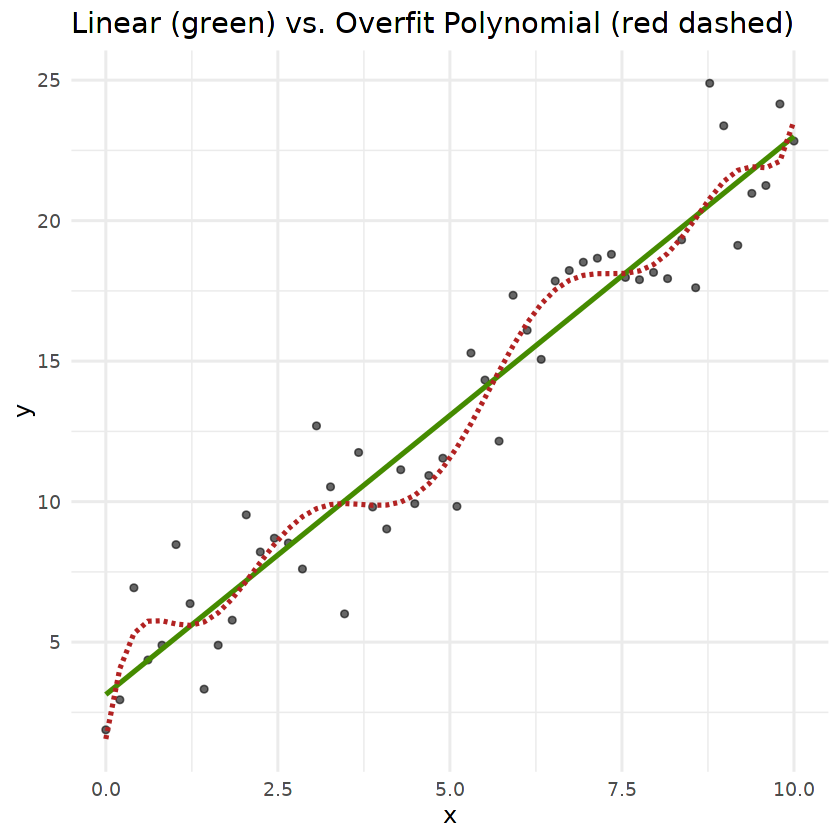

In [21]:
set.seed(123)
x <- seq(0, 10, length.out = 50)
y_true <- 3 + 2 * x
y_obs  <- y_true + rnorm(50, sd = 2)

df <- tibble(x, y_obs)

fit_lin  <- lm(y_obs ~ x)
fit_poly <- lm(y_obs ~ poly(x, 10))

pred_lin  <- tibble(x, y = predict(fit_lin))
pred_poly <- tibble(x, y = predict(fit_poly))

ggplot(df, aes(x, y_obs)) +
  geom_point(alpha = 0.6) +
  geom_line(data = pred_lin,  aes(y = y), color = "chartreuse4", linewidth = 1.1) +
  geom_line(data = pred_poly, aes(y = y), color = "firebrick",
            linewidth = 1.1, linetype = "dashed") +
  labs(
    title = "Linear (green) vs. Overfit Polynomial (red dashed)",
    x = "x", y = "y"
  ) +
  theme_minimal(base_size = 14)

---

## Part 6: When Least Squares Doesn't Work

When the model is **nonlinear in the parameters**, there is no algebraic solution for the $b$'s. For example:

$$
\hat{y} = b_0 + b_1 e^{b_2 x}
\qquad \text{or} \qquad
\hat{y} = \frac{b_0}{1 + e^{-b_1(x - b_2)}}
$$

Here $b_2$ appears *inside* an exponential or denominator, so we need **numerical optimization** (iterative algorithms) instead of a closed-form formula.

---

## Summary

- Least squares chooses $(b_0, b_1)$ to **minimize SSR** — that is what `lm()` computes.
- Visualizing candidate lines + SSR builds intuition for the optimization.
- Good optimization cannot rescue a **bad model form**: inspect shapes, consider transforms or polynomial terms.
- Always evaluate generalization using **test data** — low training SSR is not enough.